<a href="https://colab.research.google.com/github/RahulSajith/uncertainty-aware-eurosat/blob/main/uncertainty_aware_eurosat_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torchgeo torch torchvision

from torchgeo.datasets import EuroSAT
from torchgeo.transforms import indices
import torch
import torch.nn as nn

# Load EuroSAT (downloads automatically)
dataset = EuroSAT(root='./data', download=True)

# Build simple CNN with Dropout
class UncertaintyCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.Dropout(0.3),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.classifier(x)

print(f"Dataset size: {len(dataset)}")
print(f"Classes: {dataset.classes}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 871.8/871.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.

In [2]:
!pip install torchgeo -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 871.8/871.8 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Device: cuda
Train: 12960, Test: 3240
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Starting training...
  Batch 0/203, Loss: 2.3019
  Batch 50/203, Loss: 1.8187
  Batch 100/203, Loss: 1.5774
  Batch 150/203, Loss: 1.7933
  Batch 200/203, Loss: 1.2909
Epoch 1/10 - Loss: 1.6577, Acc: 0.3760
  Batch 0/203, Loss: 1.4739
  Batch 50/203, Loss: 1.2950
  Batch 100/203, Loss: 1.2161
  Batch 150/203, Loss: 1.1842
  Batch 200/203, Loss: 0.9315
Epoch 2/10 - Loss: 1.1817, Acc: 0.5682
  Batch 0/203, Loss: 1.1778
  Batch 50/203, Loss: 1.1460
  Batch 100/203, Loss: 0.8975
  Batch 150/203, Loss: 0.8705
  Batch 200/203, Loss: 1.0343
Epoch 3/10 - Loss: 1.0082, Acc: 0.6343
  Batch 0/203, Loss: 0.8812
  Batch 50/203, Loss: 1.0572
  Batch 100/203, Loss: 0.7767
  Batch 150/203, Loss: 1.0814
  Batch 200/203, Loss: 1.0954
Epoch 4/10 - Loss: 0.9290, Acc: 0.6659
  Batch 0/203, Loss: 0.6813
  Batch 50/203, Loss: 0

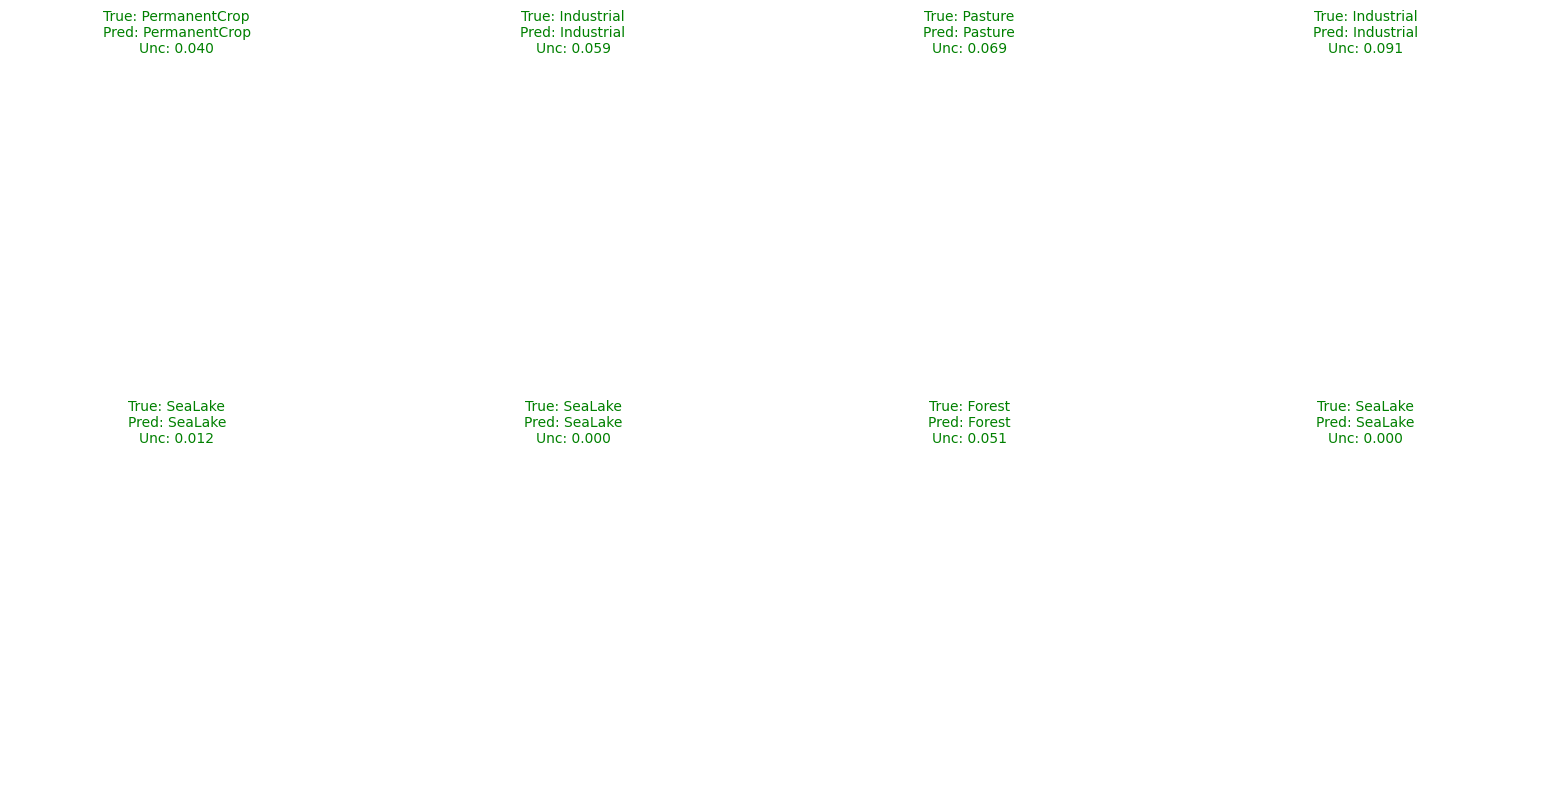


Saved: uncertainty_cnn_eurosat.pth, sample_results.json, uncertainty_visualization.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from torchgeo.datasets import EuroSAT

# ============================================================
# 0. CHECK GPU
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if not torch.cuda.is_available():
    print("WARNING: No GPU detected! Go to Runtime → Change runtime type → GPU")

# ============================================================
# 1. WRAPPER TO HANDLE TORCHGEO DICT FORMAT
# ============================================================

class EuroSATWrapper(Dataset):
    """Wraps torchgeo EuroSAT to return (image_tensor, label) tuples"""
    def __init__(self, eurosat_dataset):
        self.dataset = eurosat_dataset
        # torchgeo images are [C, H, W] tensors already, just need normalization
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]  # Returns dict: {'image': tensor, 'label': int}
        image = sample['image']  # [13, 64, 64] - all Sentinel-2 bands
        label = sample['label']

        # Take only RGB bands (bands 3, 2, 1 in Sentinel-2 = RGB)
        # EuroSAT in torchgeo: bands are ordered differently
        # Let's just take first 3 bands and normalize
        rgb = image[:3, :, :].float()

        # Normalize to [0, 1] if needed, then apply ImageNet normalization
        if rgb.max() > 1:
            rgb = rgb / 255.0

        rgb = self.normalize(rgb)
        return rgb, label

# Load dataset
raw_dataset = EuroSAT(root='./data', download=True, checksum=True)
dataset = EuroSATWrapper(raw_dataset)

# Split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# DataLoaders - num_workers=0 for Colab stability
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")
print(f"Classes: {raw_dataset.classes}")

# ============================================================
# 2. MODEL
# ============================================================

class UncertaintyCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.Dropout2d(0.2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.Dropout2d(0.3),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.classifier(x)

model = UncertaintyCNN(num_classes=10).to(device)

# ============================================================
# 3. TRAINING
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)

        if batch_idx % 50 == 0:
            print(f"  Batch {batch_idx}/{len(loader)}, Loss: {loss.item():.4f}")

    return total_loss / len(loader), correct / total

print("Starting training...")
for epoch in range(10):
    loss, acc = train_epoch(model, train_loader, optimizer, criterion)
    print(f"Epoch {epoch+1}/10 - Loss: {loss:.4f}, Acc: {acc:.4f}")

print("Training complete!")

# ============================================================
# 4. MC DROPOUT INFERENCE
# ============================================================

def mc_dropout_predict(model, x, n_samples=50):
    model.train()  # Keep dropout ON!
    predictions = []
    with torch.no_grad():
        for _ in range(n_samples):
            output = model(x)
            probs = F.softmax(output, dim=1)
            predictions.append(probs.cpu().numpy())

    predictions = np.array(predictions)
    mean_pred = predictions.mean(axis=0)
    epistemic_uncertainty = predictions.var(axis=0).sum(axis=1)
    predictive_entropy = -np.sum(mean_pred * np.log(mean_pred + 1e-10), axis=1)
    return mean_pred, epistemic_uncertainty, predictive_entropy

print("\nRunning MC Dropout inference...")
test_data, test_labels = next(iter(test_loader))
test_data = test_data[:8].to(device)

mean_pred, epistemic_unc, pred_entropy = mc_dropout_predict(model, test_data, n_samples=50)
pred_classes = mean_pred.argmax(axis=1)

print(f"Predicted: {pred_classes}")
print(f"Epistemic uncertainty: {epistemic_unc}")

# ============================================================
# 5. VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(8):
    ax = axes[i // 4, i % 4]

    # Denormalize for display
    img = test_data[i].cpu().permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    true_label = raw_dataset.classes[test_labels[i]]
    pred_label = raw_dataset.classes[pred_classes[i]]

    uncertainty = epistemic_unc[i]
    color = 'green' if uncertainty < 0.1 else 'orange' if uncertainty < 0.3 else 'red'

    ax.set_title(f"True: {true_label}\nPred: {pred_label}\nUnc: {uncertainty:.3f}",
                 color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('uncertainty_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6. SAVE EVERYTHING
# ============================================================

torch.save(model.state_dict(), 'uncertainty_cnn_eurosat.pth')

import json
sample_result = {
    'predicted_class': pred_classes.tolist(),
    'epistemic_uncertainty': epistemic_unc.tolist(),
    'predictive_entropy': pred_entropy.tolist()
}
with open('sample_results.json', 'w') as f:
    json.dump(sample_result, f, indent=2)

print("\nSaved: uncertainty_cnn_eurosat.pth, sample_results.json, uncertainty_visualization.png")

# Download
from google.colab import files
files.download('uncertainty_cnn_eurosat.pth')
files.download('sample_results.json')
files.download('uncertainty_visualization.png')